<a href="https://colab.research.google.com/github/MarriRohan/Quantum-Computing/blob/main/Quantum_Algorithm_Demonstrator%20Produt%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Qiskit

In [ ]:
!pip install -q qiskit==2.4.2 qiskit-aer==0.17.2 "matplotlib>=3.8" pylatexenc==2.11 "numpy>=2.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00


Check versions

In [ ]:
import sys
import qiskit
import qiskit_aer
import numpy
import matplotlib

print("Python:", sys.version)
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("NumPy:", numpy.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Qiskit: 2.4.2
Qiskit Aer: 0.17.2
NumPy: 2.1.3
Matplotlib: 3.10.0


Main Product 2 code

In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


# ============================================================
# SIMULATOR
# ============================================================

SIMULATOR = AerSimulator()


# ============================================================
# COMMON FUNCTIONS
# ============================================================

def validate_bits(bits, name="bit string"):
    bits = bits.replace(" ", "")
    if not bits or set(bits) - {"0", "1"}:
        raise ValueError(f"{name} must contain only 0 and 1.")
    return bits


def simulate_counts(circuit, shots=2048, seed=42):
    compiled = transpile(
        circuit,
        SIMULATOR,
        optimization_level=1
    )

    job = SIMULATOR.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    return job.result().get_counts(compiled)


def most_likely(counts):
    return max(counts, key=counts.get)


def save_artifacts(circuit, counts, name, output_dir="outputs"):
    folder = Path(output_dir)
    folder.mkdir(parents=True, exist_ok=True)

    circuit_path = folder / f"{name}_circuit.png"
    histogram_path = folder / f"{name}_histogram.png"

    circuit_figure = circuit.draw(
        output="mpl",
        fold=-1,
        idle_wires=True
    )

    circuit_figure.savefig(
        circuit_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close(circuit_figure)

    histogram_figure = plot_histogram(
        counts,
        title=f"{name}: measurement counts"
    )

    histogram_figure.savefig(
        histogram_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close(histogram_figure)

    return circuit_path, histogram_path


# ============================================================
# 1. DEUTSCH-JOZSA
# ============================================================

def deutsch_jozsa_circuit(
    n=4,
    oracle_type="balanced",
    mask="1011",
    constant_bit=0
):

    if n < 1:
        raise ValueError("n must be at least 1.")

    qc = QuantumCircuit(
        n + 1,
        n,
        name="Deutsch-Jozsa"
    )

    output = n

    # Output qubit |1>
    qc.x(output)

    # Hadamard gates
    qc.h(range(n + 1))

    qc.barrier(label="oracle")

    if oracle_type == "constant":

        if constant_bit == 1:
            qc.x(output)

    elif oracle_type == "balanced":

        mask = validate_bits(mask, "mask")

        if len(mask) != n or int(mask, 2) == 0:
            raise ValueError(
                "Balanced mask must be n bits and nonzero."
            )

        for qubit, bit in enumerate(reversed(mask)):
            if bit == "1":
                qc.cx(qubit, output)

    else:
        raise ValueError(
            "oracle_type must be constant or balanced."
        )

    qc.barrier(label="interfere")

    qc.h(range(n))

    qc.measure(
        range(n),
        range(n)
    )

    return qc


def run_deutsch_jozsa(
    n=4,
    oracle_type="balanced",
    mask="1011",
    constant_bit=0,
    shots=2048
):

    qc = deutsch_jozsa_circuit(
        n,
        oracle_type,
        mask,
        constant_bit
    )

    counts = simulate_counts(
        qc,
        shots
    )

    observed = most_likely(counts)

    decision = (
        "constant"
        if observed == "0" * n
        else "balanced"
    )

    return {
        "algorithm": "Deutsch-Jozsa",
        "decision": decision,
        "counts": counts,
        "circuit": qc,
        "quantum_queries": 1,
        "classical_worst_case": 2 ** (n - 1) + 1
    }


# ============================================================
# 2. BERNSTEIN-VAZIRANI
# ============================================================

def bernstein_vazirani_circuit(secret="1011"):

    secret = validate_bits(
        secret,
        "secret"
    )

    n = len(secret)

    qc = QuantumCircuit(
        n + 1,
        n,
        name="Bernstein-Vazirani"
    )

    output = n

    qc.x(output)

    qc.h(range(n + 1))

    qc.barrier(label="oracle")

    for qubit, bit in enumerate(
        reversed(secret)
    ):

        if bit == "1":
            qc.cx(
                qubit,
                output
            )

    qc.barrier(label="decode")

    qc.h(range(n))

    qc.measure(
        range(n),
        range(n)
    )

    return qc


def run_bernstein_vazirani(
    secret="1011",
    shots=2048
):

    qc = bernstein_vazirani_circuit(
        secret
    )

    counts = simulate_counts(
        qc,
        shots
    )

    return {
        "algorithm": "Bernstein-Vazirani",
        "secret": secret,
        "recovered": most_likely(counts),
        "counts": counts,
        "circuit": qc,
        "quantum_queries": 1,
        "classical_queries": len(secret)
    }


# ============================================================
# 3. SIMON'S ALGORITHM
# ============================================================

def simon_circuit(secret="110"):

    secret = validate_bits(
        secret,
        "secret"
    )

    if int(secret, 2) == 0:
        raise ValueError(
            "Simon's secret must be nonzero."
        )

    n = len(secret)

    qc = QuantumCircuit(
        2 * n,
        n,
        name="Simon"
    )

    qc.h(range(n))

    qc.barrier(
        label="two-to-one oracle"
    )

    # Copy x to output register
    for i in range(n):
        qc.cx(
            i,
            n + i
        )

    # Compute f(x) = x XOR x_p*s
    little_endian_secret = list(
        reversed(secret)
    )

    pivot = little_endian_secret.index("1")

    for i, bit in enumerate(
        little_endian_secret
    ):

        if bit == "1":
            qc.cx(
                pivot,
                n + i
            )

    qc.barrier(
        label="sample y"
    )

    qc.h(range(n))

    qc.measure(
        range(n),
        range(n)
    )

    return qc


def gf2_dot(left, right):

    return sum(
        int(a) * int(b)
        for a, b in zip(left, right)
    ) % 2


def recover_simon_candidates(
    counts,
    n
):

    equations = [
        key.replace(" ", "")
        for key in counts
    ]

    candidates = []

    for value in range(
        1,
        2 ** n
    ):

        candidate = f"{value:0{n}b}"

        if all(
            gf2_dot(
                y,
                candidate
            ) == 0
            for y in equations
        ):

            candidates.append(
                candidate
            )

    return candidates


def run_simon(
    secret="110",
    shots=4096
):

    qc = simon_circuit(
        secret
    )

    counts = simulate_counts(
        qc,
        shots
    )

    candidates = recover_simon_candidates(
        counts,
        len(secret)
    )

    return {
        "algorithm": "Simon",
        "secret": secret,
        "recovered_candidates": candidates,
        "counts": counts,
        "circuit": qc,
        "quantum_queries": f"O({len(secret)})",
        "classical_queries":
            f"Theta(2^({len(secret)}/2)) expected"
    }


# ============================================================
# 4. GROVER'S SEARCH
# ============================================================

def apply_phase_mark(
    qc,
    marked
):

    little_endian = list(
        reversed(marked)
    )

    for qubit, bit in enumerate(
        little_endian
    ):

        if bit == "0":
            qc.x(qubit)

    target = len(marked) - 1

    qc.h(target)

    if len(marked) == 1:
        qc.x(target)
    else:
        qc.mcx(
            list(range(target)),
            target
        )

    qc.h(target)

    for qubit, bit in enumerate(
        little_endian
    ):

        if bit == "0":
            qc.x(qubit)


def apply_diffuser(
    qc,
    n
):

    qc.h(range(n))
    qc.x(range(n))

    target = n - 1

    qc.h(target)

    if n == 1:
        qc.x(target)
    else:
        qc.mcx(
            list(range(target)),
            target
        )

    qc.h(target)

    qc.x(range(n))
    qc.h(range(n))


def grover_circuit(
    marked="101",
    iterations=None
):

    marked = validate_bits(
        marked,
        "marked state"
    )

    n = len(marked)

    if iterations is None:
        iterations = max(
            1,
            math.floor(
                (math.pi / 4)
                * math.sqrt(2 ** n)
            )
        )

    qc = QuantumCircuit(
        n,
        n,
        name="Grover"
    )

    qc.h(range(n))

    for _ in range(iterations):

        qc.barrier(
            label="oracle"
        )

        apply_phase_mark(
            qc,
            marked
        )

        qc.barrier(
            label="diffuser"
        )

        apply_diffuser(
            qc,
            n
        )

    qc.measure(
        range(n),
        range(n)
    )

    return qc, iterations


def run_grover(
    marked="101",
    shots=4096
):

    marked = validate_bits(
        marked,
        "marked state"
    )

    qc, iterations = grover_circuit(
        marked
    )

    counts = simulate_counts(
        qc,
        shots
    )

    success_probability = (
        counts.get(marked, 0)
        / shots
    )

    return {
        "algorithm": "Grover",
        "marked": marked,
        "recovered": most_likely(counts),
        "iterations": iterations,
        "success_probability":
            success_probability,
        "counts": counts,
        "circuit": qc,
        "quantum_queries":
            f"O(sqrt(2^{len(marked)}))",
        "classical_queries":
            f"O(2^{len(marked)})"
    }


# ============================================================
# 5. QUANTUM FOURIER TRANSFORM
# ============================================================

def qft_round_trip_circuit(
    n=3,
    value=5
):

    if n < 1 or not (
        0 <= value < 2 ** n
    ):
        raise ValueError(
            "Require n >= 1 and "
            "0 <= value < 2**n."
        )

    qc = QuantumCircuit(
        n,
        n,
        name="QFT round trip"
    )

    # Encode |value>
    for qubit in range(n):

        if (value >> qubit) & 1:
            qc.x(qubit)

    qc.barrier(
        label="QFT"
    )

    qc.append(
        QFTGate(n),
        range(n)
    )

    qc.barrier(
        label="inverse QFT"
    )

    qc.append(
        QFTGate(n).inverse(),
        range(n)
    )

    qc.measure(
        range(n),
        range(n)
    )

    return qc


def qft_state(
    n=3,
    value=5
):

    qc = QuantumCircuit(n)

    for qubit in range(n):

        if (value >> qubit) & 1:
            qc.x(qubit)

    qc.append(
        QFTGate(n),
        range(n)
    )

    return Statevector.from_instruction(
        qc
    )


def run_qft(
    n=3,
    value=5,
    shots=2048
):

    qc = qft_round_trip_circuit(
        n,
        value
    )

    counts = simulate_counts(
        qc,
        shots
    )

    state = qft_state(
        n,
        value
    )

    phase_degrees = np.angle(
        state.data,
        deg=True
    )

    return {
        "algorithm": "QFT",
        "input_value": value,
        "expected_bits":
            f"{value:0{n}b}",
        "recovered":
            most_likely(counts),
        "counts": counts,
        "phase_degrees":
            np.round(
                phase_degrees,
                1
            ).tolist(),
        "circuit": qc,
        "quantum_gate_complexity":
            f"O({n}^2)",
        "classical_fft":
            f"O({n}*2^{n})"
    }


print("All 5 quantum algorithms loaded successfully.")

All 5 quantum algorithms loaded successfully.


Create output folder

In [ ]:
from pathlib import Path

Path("outputs").mkdir(
    exist_ok=True
)

print("outputs folder created.")

outputs folder created.


RUN ALL 5 ALGORITHMS

In [ ]:
print("=" * 70)
print("PRODUCT 2: QUANTUM ALGORITHM DEMONSTRATOR")
print("=" * 70)


# ------------------------------------------------------------
# Deutsch-Jozsa
# ------------------------------------------------------------

dj = run_deutsch_jozsa(
    n=4,
    oracle_type="balanced",
    mask="1011",
    shots=2048
)

print("\nDEUTSCH-JOZSA")
print("Decision:", dj["decision"])
print("Counts:", dj["counts"])
print("Quantum queries:", dj["quantum_queries"])
print(
    "Classical worst case:",
    dj["classical_worst_case"]
)

save_artifacts(
    dj["circuit"],
    dj["counts"],
    "deutsch_jozsa"
)


# ------------------------------------------------------------
# Bernstein-Vazirani
# ------------------------------------------------------------

bv = run_bernstein_vazirani(
    secret="1011",
    shots=2048
)

print("\nBERNSTEIN-VAZIRANI")
print("Secret:", bv["secret"])
print("Recovered:", bv["recovered"])
print("Counts:", bv["counts"])
print("Quantum queries:", bv["quantum_queries"])
print("Classical queries:", bv["classical_queries"])

save_artifacts(
    bv["circuit"],
    bv["counts"],
    "bernstein_vazirani"
)


# ------------------------------------------------------------
# Simon
# ------------------------------------------------------------

simon = run_simon(
    secret="110",
    shots=4096
)

print("\nSIMON")
print("Secret:", simon["secret"])
print(
    "Recovered candidates:",
    simon["recovered_candidates"]
)
print("Counts:", simon["counts"])
print(
    "Quantum queries:",
    simon["quantum_queries"]
)
print(
    "Classical queries:",
    simon["classical_queries"]
)

save_artifacts(
    simon["circuit"],
    simon["counts"],
    "simon"
)


# ------------------------------------------------------------
# Grover
# ------------------------------------------------------------

grover = run_grover(
    marked="101",
    shots=4096
)

print("\nGROVER")
print("Marked state:", grover["marked"])
print("Recovered:", grover["recovered"])
print("Iterations:", grover["iterations"])
print(
    "Success probability:",
    grover["success_probability"]
)
print("Counts:", grover["counts"])

save_artifacts(
    grover["circuit"],
    grover["counts"],
    "grover"
)


# ------------------------------------------------------------
# QFT
# ------------------------------------------------------------

qft = run_qft(
    n=3,
    value=5,
    shots=2048
)

print("\nQFT")
print("Input value:", qft["input_value"])
print("Expected bits:", qft["expected_bits"])
print("Recovered:", qft["recovered"])
print("Counts:", qft["counts"])
print(
    "Phase degrees:",
    qft["phase_degrees"]
)

save_artifacts(
    qft["circuit"],
    qft["counts"],
    "qft"
)


print("\n" + "=" * 70)
print("ALL 5 ALGORITHMS COMPLETED")
print("=" * 70)

PRODUCT 2: QUANTUM ALGORITHM DEMONSTRATOR

DEUTSCH-JOZSA
Decision: balanced
Counts: {'1011': 2048}
Quantum queries: 1
Classical worst case: 9

BERNSTEIN-VAZIRANI
Secret: 1011
Recovered: 1011
Counts: {'1011': 2048}
Quantum queries: 1
Classical queries: 4

SIMON
Secret: 110
Recovered candidates: ['110']
Counts: {'111': 1037, '000': 993, '001': 1039, '110': 1027}
Quantum queries: O(3)
Classical queries: Theta(2^(3/2)) expected

GROVER
Marked state: 101
Recovered: 101
Iterations: 2
Success probability: 0.949462890625
Counts: {'100': 21, '111': 31, '011': 30, '110': 41, '000': 33, '010': 26, '001': 25, '101': 3889}

QFT
Input value: 5
Expected bits: 101
Recovered: 101
Counts: {'101': 2048}
Phase degrees: [0.0, -135.0, 90.0, -45.0, 180.0, 45.0, -90.0, 135.0]

ALL 5 ALGORITHMS COMPLETED


In [ ]:
from qiskit import transpile

algorithms = {
    "Deutsch-Jozsa": dj["circuit"],
    "Bernstein-Vazirani": bv["circuit"],
    "Simon": simon["circuit"],
    "Grover": grover["circuit"],
    "QFT": qft["circuit"]
}

print("TRANSPILED CIRCUIT GATE COUNTS")
print("=" * 40)

for name, circuit in algorithms.items():
    transpiled = transpile(circuit, optimization_level=1)

    print(f"\n{name}")
    print("Total gates:", transpiled.size())
    print("Gate counts:", transpiled.count_ops())

TRANSPILED CIRCUIT GATE COUNTS

Deutsch-Jozsa
Total gates: 16
Gate counts: OrderedDict({'h': 8, 'measure': 4, 'cx': 3, 'barrier': 2, 'u2': 1})

Bernstein-Vazirani
Total gates: 16
Gate counts: OrderedDict({'h': 8, 'measure': 4, 'cx': 3, 'barrier': 2, 'u2': 1})

Simon
Total gates: 12
Gate counts: OrderedDict({'h': 6, 'cx': 3, 'measure': 3, 'barrier': 2})

Grover
Total gates: 30
Gate counts: OrderedDict({'u2': 8, 'h': 7, 'barrier': 4, 'x': 4, 'ccx': 4, 'u1': 4, 'measure': 3})

QFT
Total gates: 13
Gate counts: OrderedDict({'h': 3, 'cp': 3, 'measure': 3, 'x': 2, 'barrier': 2, 'swap': 1, 'qft_dg': 1})


CHECK PNG FILES

In [ ]:
import os

print("FILES CREATED IN OUTPUTS:\n")

for file in sorted(
    os.listdir("outputs")
):

    print(file)

FILES CREATED IN OUTPUTS:

bernstein_vazirani_circuit.png
bernstein_vazirani_histogram.png
deutsch_jozsa_circuit.png
deutsch_jozsa_histogram.png
grover_circuit.png
grover_histogram.png
qft_circuit.png
qft_histogram.png
simon_circuit.png
simon_histogram.png


DISPLAY ALL CIRCUITS AND HISTOGRAMS


bernstein_vazirani_circuit.png


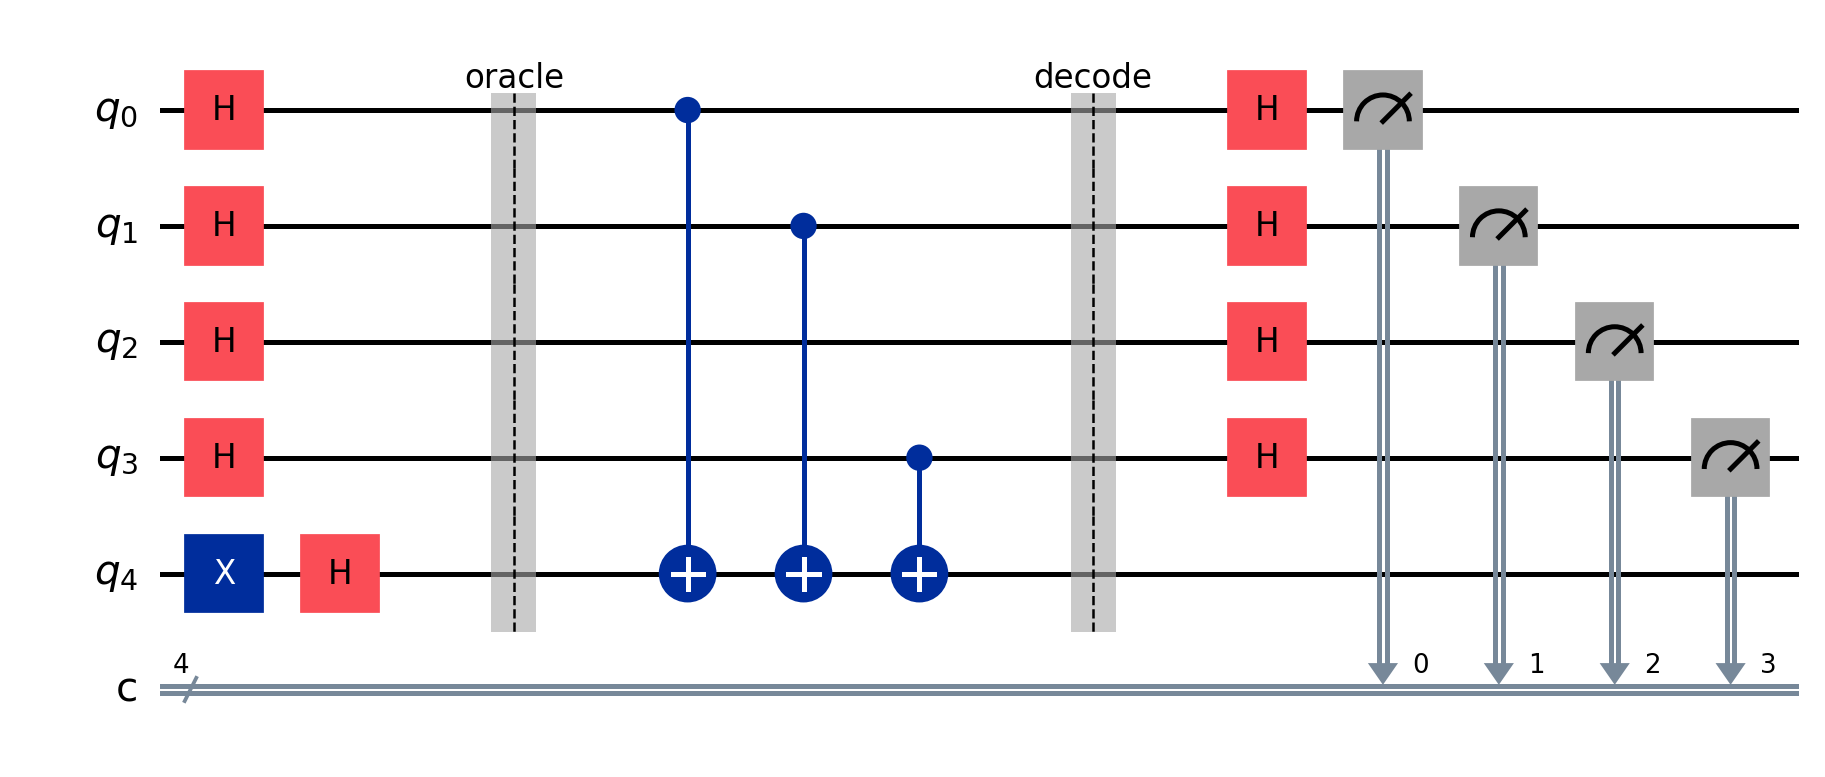


bernstein_vazirani_histogram.png


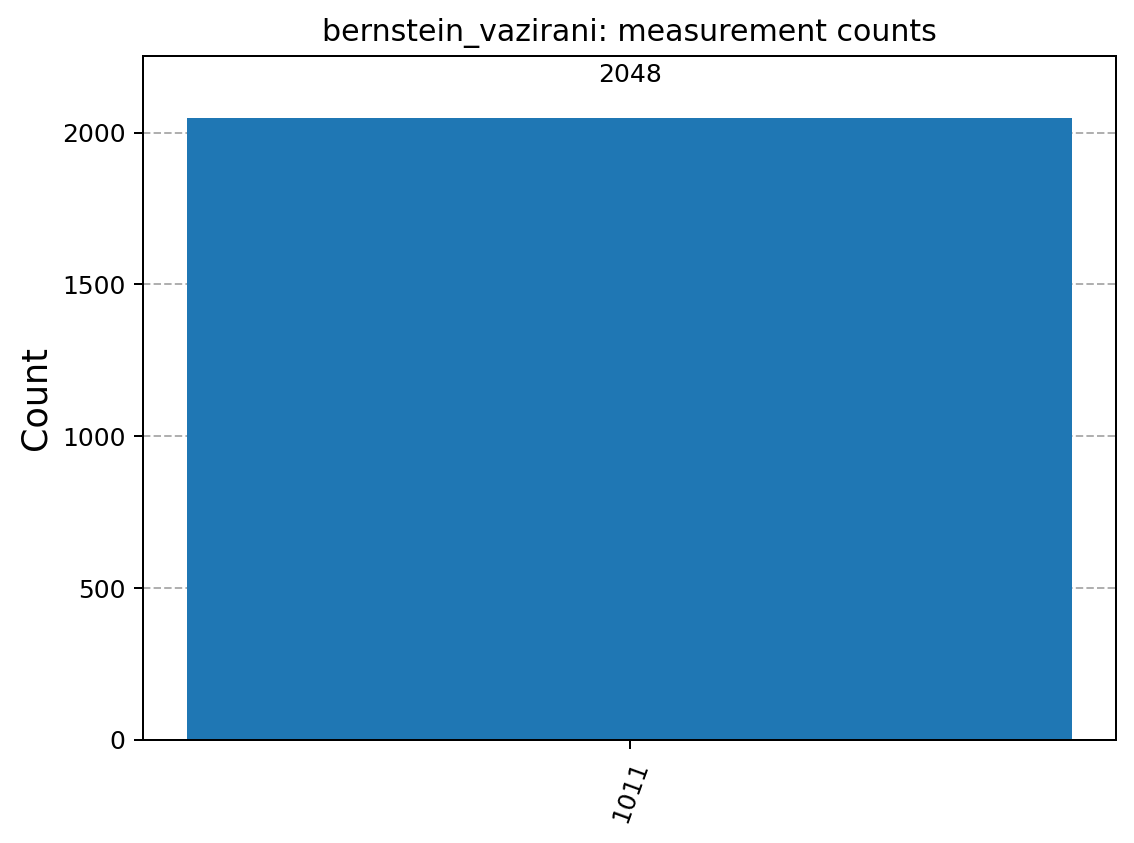


deutsch_jozsa_circuit.png


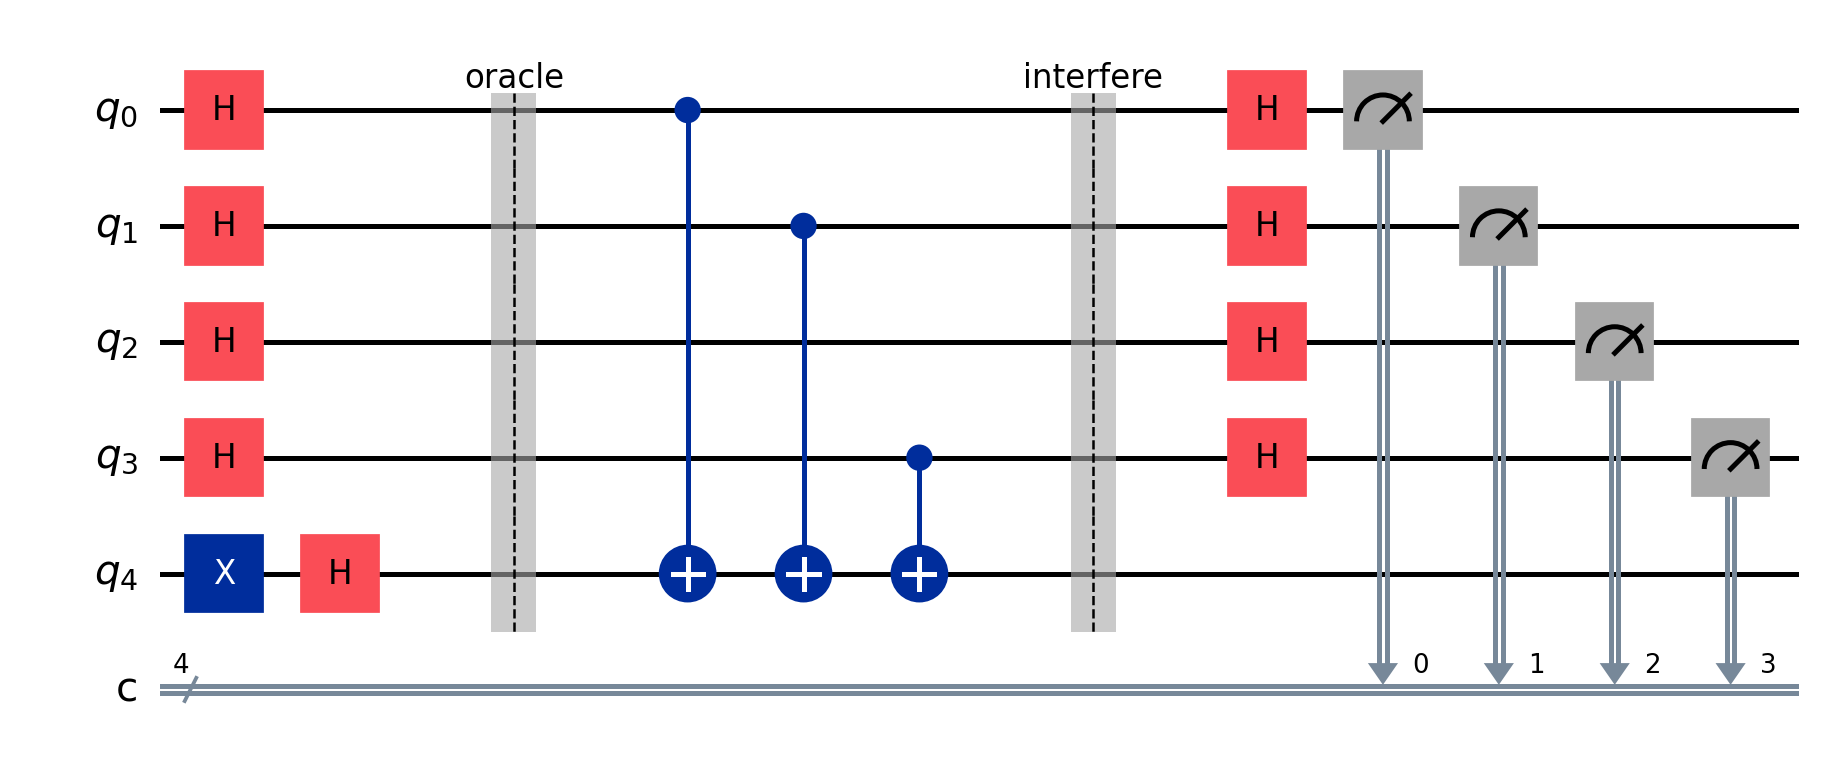


deutsch_jozsa_histogram.png


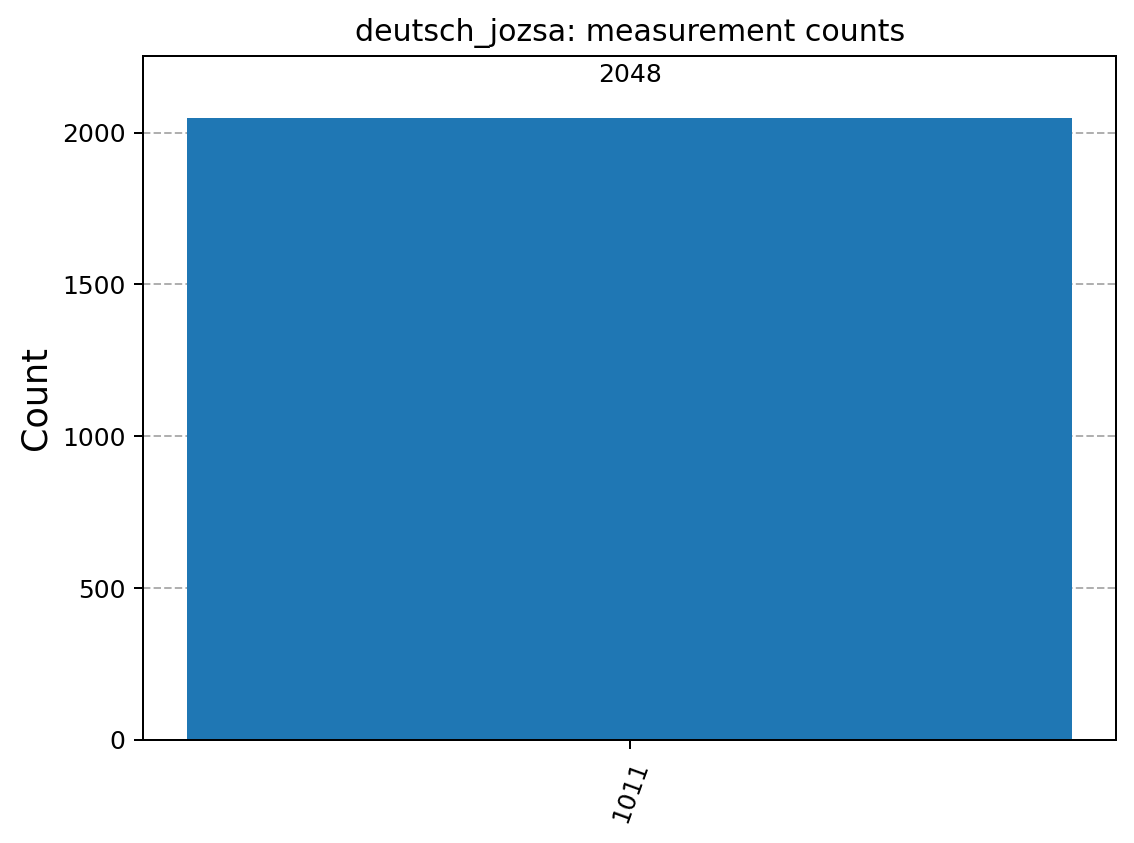


grover_circuit.png


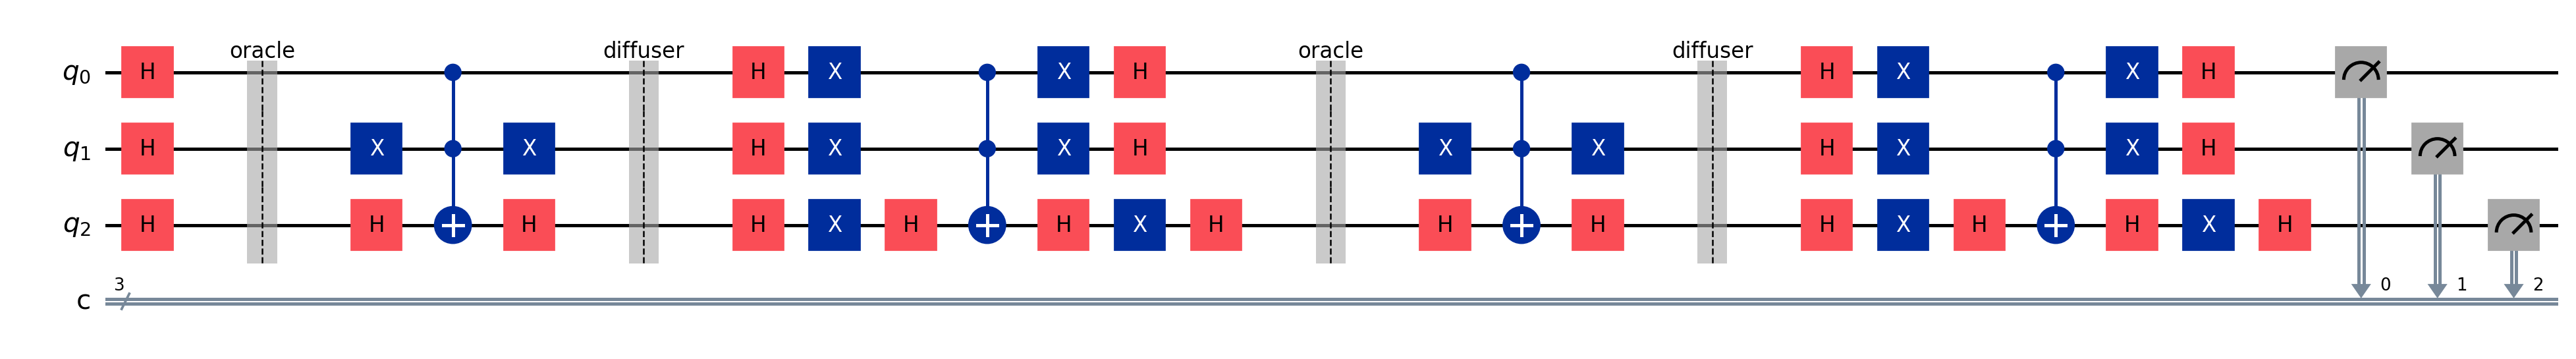


grover_histogram.png


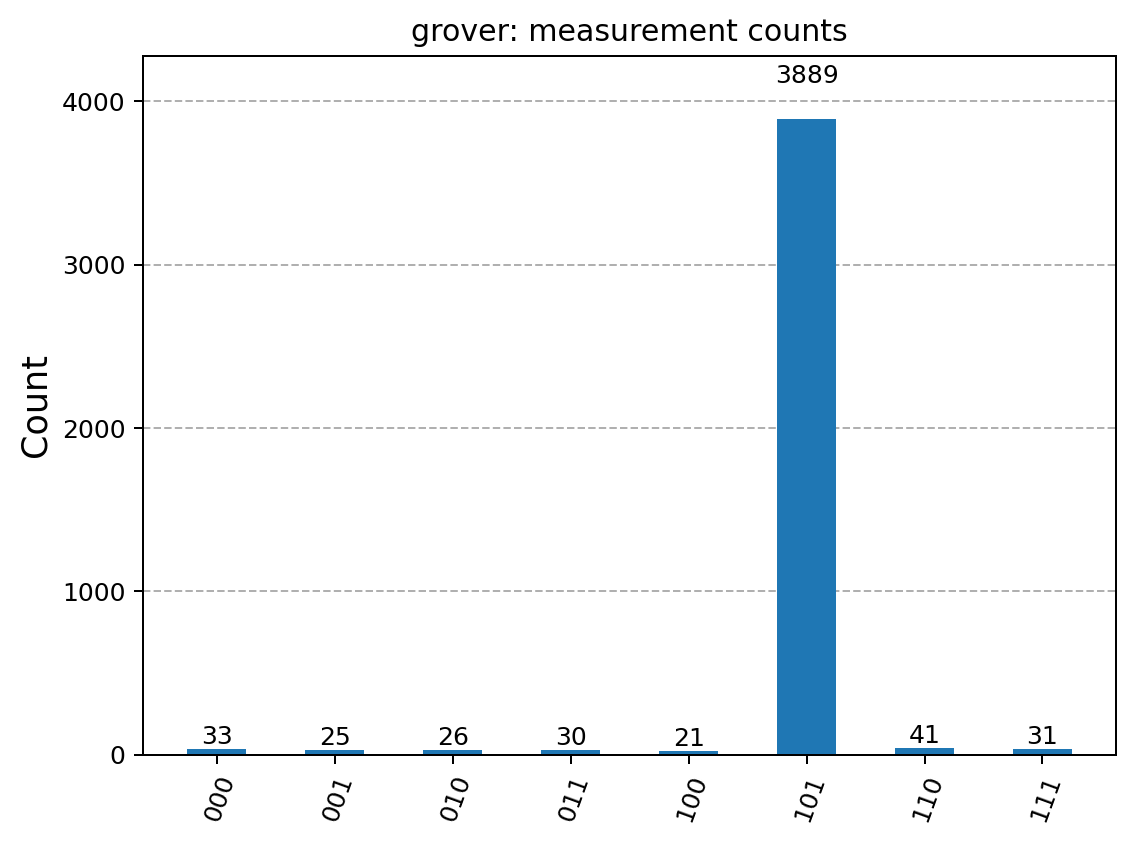


qft_circuit.png


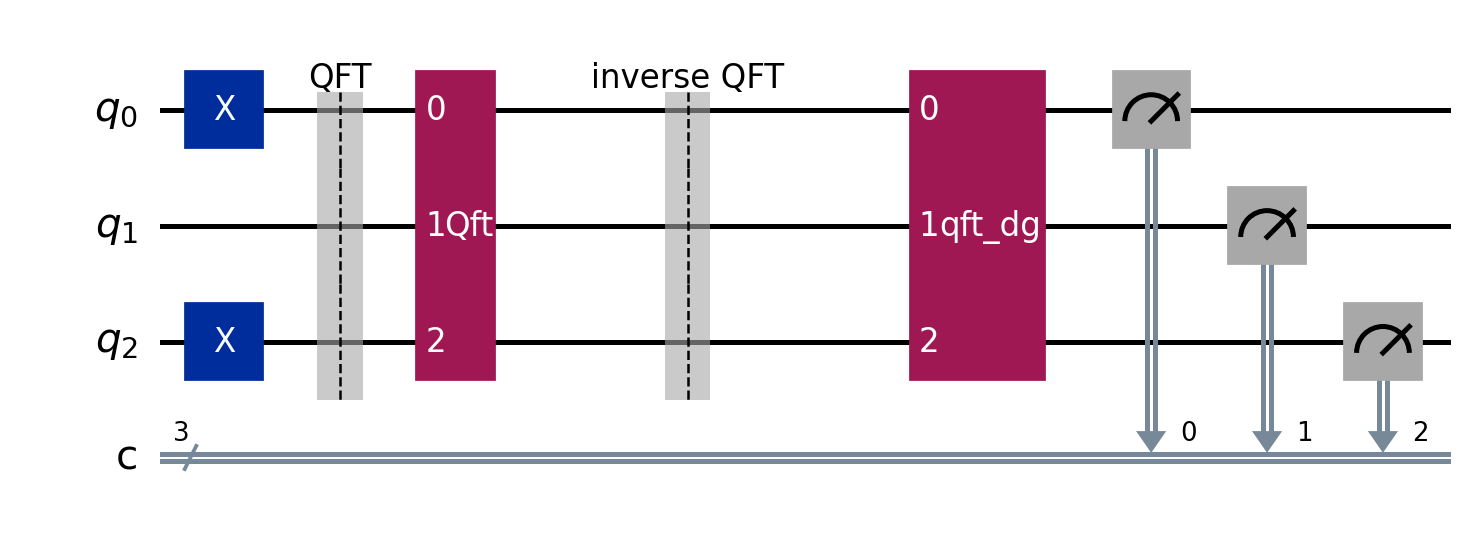


qft_histogram.png


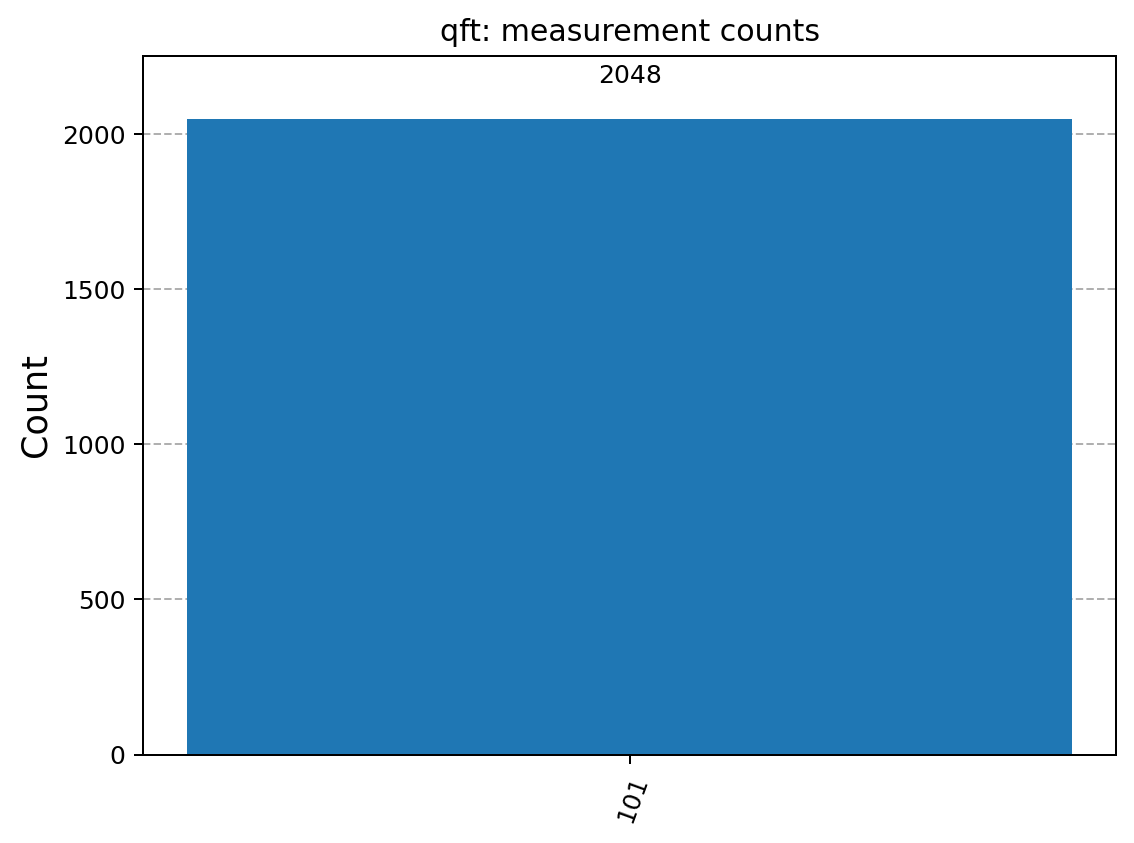


simon_circuit.png


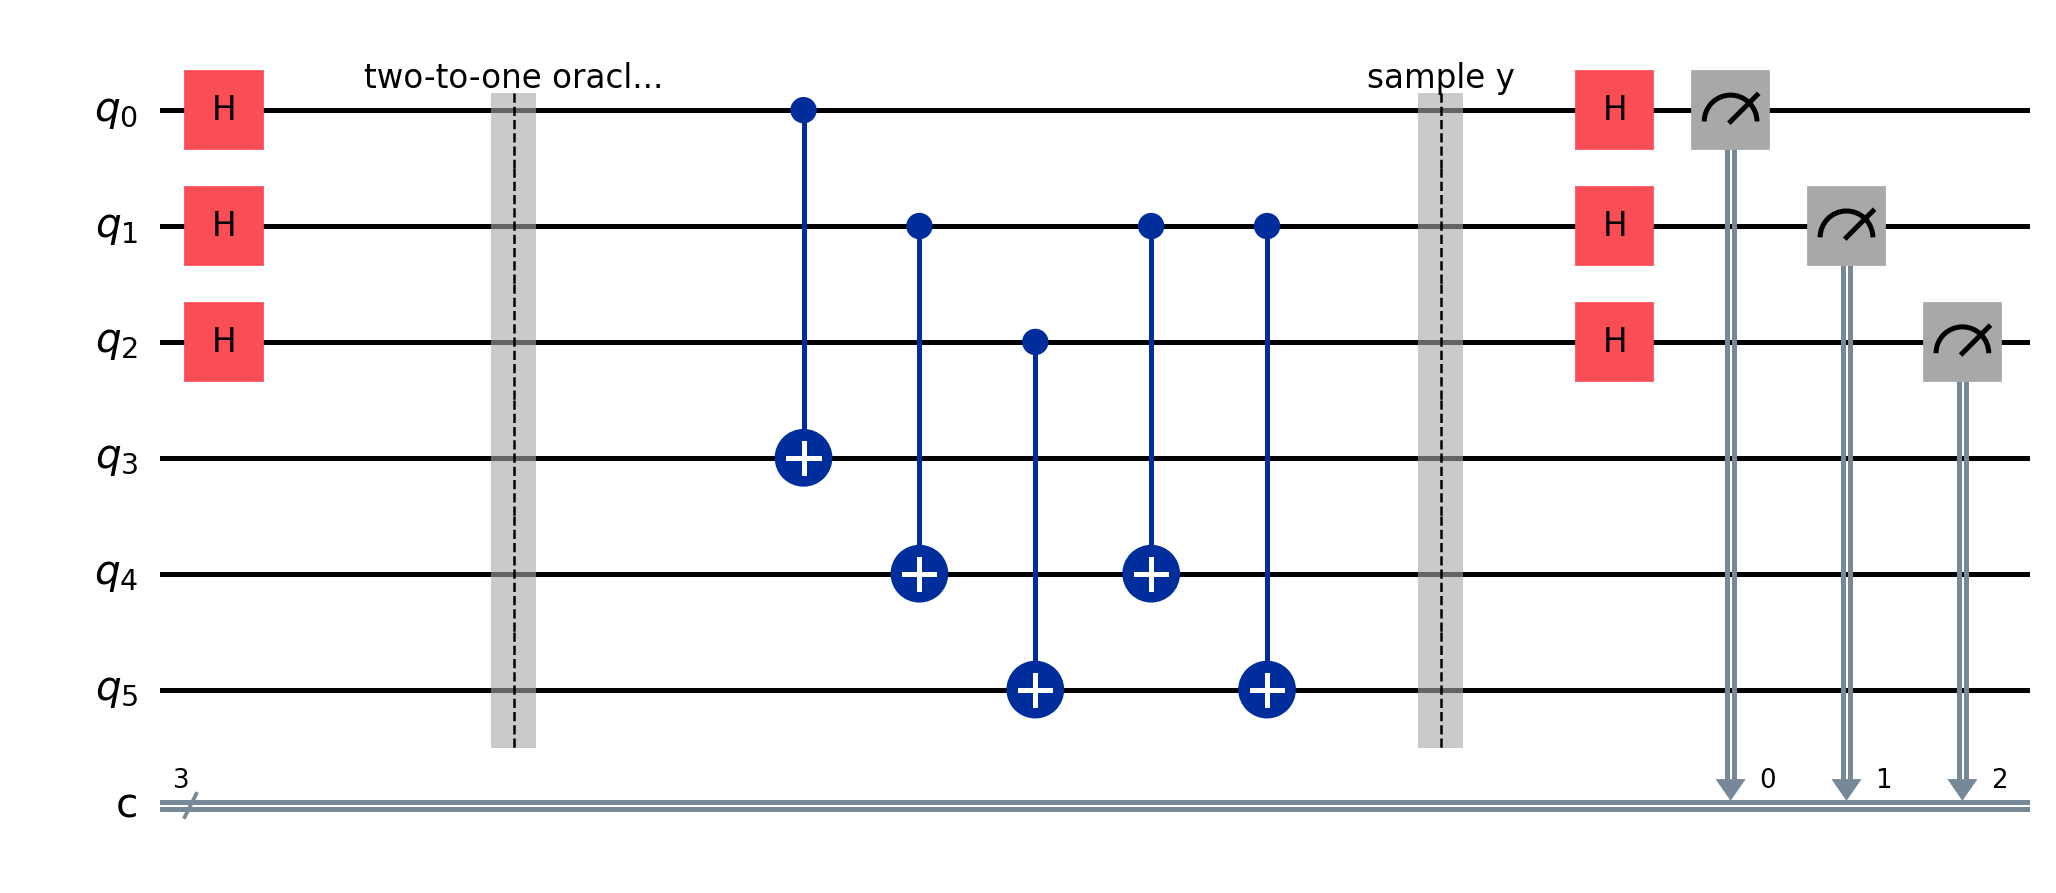


simon_histogram.png


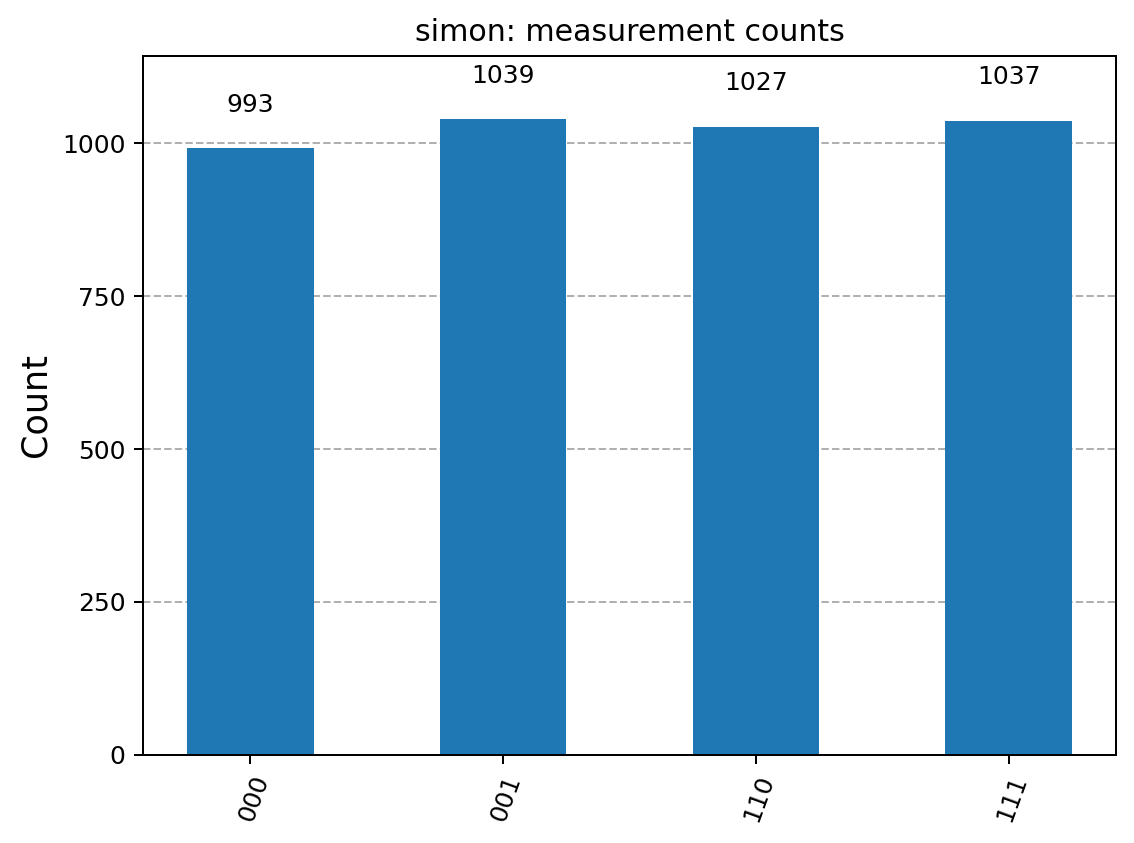

In [ ]:
from IPython.display import display, Image
import os

for file in sorted(
    os.listdir("outputs")
):

    if file.endswith(".png"):

        print("\n" + "=" * 60)
        print(file)
        print("=" * 60)

        display(
            Image(
                filename="outputs/" + file
            )
        )

DEUTSCH-JOZSA EXPERIMENTS

In [ ]:
print("DEUTSCH-JOZSA EXPERIMENTS")
print("=" * 60)


# Constant 0
result = run_deutsch_jozsa(
    n=4,
    oracle_type="constant",
    constant_bit=0,
    shots=2048
)

print("\nConstant 0")
print("Counts:", result["counts"])
print("Decision:", result["decision"])


# Constant 1
result = run_deutsch_jozsa(
    n=4,
    oracle_type="constant",
    constant_bit=1,
    shots=2048
)

print("\nConstant 1")
print("Counts:", result["counts"])
print("Decision:", result["decision"])


# Balanced mask 1011
result = run_deutsch_jozsa(
    n=4,
    oracle_type="balanced",
    mask="1011",
    shots=2048
)

print("\nBalanced 1011")
print("Counts:", result["counts"])
print("Decision:", result["decision"])


# Balanced mask 1101
result = run_deutsch_jozsa(
    n=4,
    oracle_type="balanced",
    mask="1101",
    shots=2048
)

print("\nBalanced 1101")
print("Counts:", result["counts"])
print("Decision:", result["decision"])

DEUTSCH-JOZSA EXPERIMENTS

Constant 0
Counts: {'0000': 2048}
Decision: constant

Constant 1
Counts: {'0000': 2048}
Decision: constant

Balanced 1011
Counts: {'1011': 2048}
Decision: balanced

Balanced 1101
Counts: {'1101': 2048}
Decision: balanced


BERNSTEIN-VAZIRANI EXPERIMENTS

In [ ]:
print("BERNSTEIN-VAZIRANI EXPERIMENTS")
print("=" * 60)


for secret in [
    "101",
    "1011",
    "11010"
]:

    result = run_bernstein_vazirani(
        secret=secret,
        shots=2048
    )

    print("\nSecret:", secret)
    print(
        "Recovered:",
        result["recovered"]
    )
    print(
        "Quantum queries:",
        result["quantum_queries"]
    )
    print(
        "Classical queries:",
        result["classical_queries"]
    )

BERNSTEIN-VAZIRANI EXPERIMENTS

Secret: 101
Recovered: 101
Quantum queries: 1
Classical queries: 3

Secret: 1011
Recovered: 1011
Quantum queries: 1
Classical queries: 4

Secret: 11010
Recovered: 11010
Quantum queries: 1
Classical queries: 5


SIMON EXPERIMENTS

In [ ]:
print("SIMON EXPERIMENTS")
print("=" * 60)


for secret in [
    "110",
    "101"
]:

    result = run_simon(
        secret=secret,
        shots=4096
    )

    print("\nSecret:", secret)

    print(
        "Recovered candidates:",
        result["recovered_candidates"]
    )

    print(
        "Counts:",
        result["counts"]
    )

SIMON EXPERIMENTS

Secret: 110
Recovered candidates: ['110']
Counts: {'111': 1037, '000': 993, '001': 1039, '110': 1027}

Secret: 101
Recovered candidates: ['101']
Counts: {'111': 1037, '101': 1039, '000': 993, '010': 1027}


GROVER EXPERIMENTS

In [ ]:
print("GROVER EXPERIMENTS")
print("=" * 60)


for target in [
    "000",
    "101",
    "111"
]:

    result = run_grover(
        marked=target,
        shots=4096
    )

    print("\nTarget:", target)
    print(
        "Recovered:",
        result["recovered"]
    )
    print(
        "Iterations:",
        result["iterations"]
    )
    print(
        "Success probability:",
        result["success_probability"]
    )

GROVER EXPERIMENTS

Target: 000
Recovered: 000
Iterations: 2
Success probability: 0.94921875

Target: 101
Recovered: 101
Iterations: 2
Success probability: 0.949462890625

Target: 111
Recovered: 111
Iterations: 2
Success probability: 0.951416015625


QFT EXPERIMENTS

In [ ]:
print("QFT EXPERIMENTS")
print("=" * 60)


for value in [
    0,
    1,
    3,
    5
]:

    result = run_qft(
        n=3,
        value=value,
        shots=2048
    )

    print("\nInput value:", value)

    print(
        "Expected bits:",
        result["expected_bits"]
    )

    print(
        "Recovered:",
        result["recovered"]
    )

    print(
        "Counts:",
        result["counts"]
    )

    print(
        "Phase degrees:",
        result["phase_degrees"]
    )

QFT EXPERIMENTS

Input value: 0
Expected bits: 000
Recovered: 000
Counts: {'000': 2048}
Phase degrees: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Input value: 1
Expected bits: 001
Recovered: 001
Counts: {'001': 2048}
Phase degrees: [0.0, 45.0, 90.0, 135.0, 180.0, -135.0, -90.0, -45.0]

Input value: 3
Expected bits: 011
Recovered: 011
Counts: {'011': 2048}
Phase degrees: [0.0, 135.0, -90.0, 45.0, 180.0, -45.0, 90.0, -135.0]

Input value: 5
Expected bits: 101
Recovered: 101
Counts: {'101': 2048}
Phase degrees: [0.0, -135.0, 90.0, -45.0, 180.0, 45.0, -90.0, 135.0]


FINAL CHECK

In [ ]:
import os

files = sorted(
    os.listdir("outputs")
)

print("TOTAL PNG FILES:", len(files))
print()

for file in files:
    print("✓", file)

TOTAL PNG FILES: 10

✓ bernstein_vazirani_circuit.png
✓ bernstein_vazirani_histogram.png
✓ deutsch_jozsa_circuit.png
✓ deutsch_jozsa_histogram.png
✓ grover_circuit.png
✓ grover_histogram.png
✓ qft_circuit.png
✓ qft_histogram.png
✓ simon_circuit.png
✓ simon_histogram.png


FINAL COMPLEXITY COMPARISON

In [ ]:
print("=" * 70)
print("QUANTUM VS CLASSICAL COMPLEXITY")
print("=" * 70)

print(
    "\nDeutsch-Jozsa:"
    "\nQuantum = 1 oracle query"
    "\nClassical = 2^(n-1)+1 worst case"
)

print(
    "\nBernstein-Vazirani:"
    "\nQuantum = 1 oracle query"
    "\nClassical = n queries"
)

print(
    "\nSimon's Algorithm:"
    "\nQuantum = O(n) oracle samples"
    "\nClassical = Theta(2^(n/2)) expected queries"
)

print(
    "\nGrover:"
    "\nQuantum = O(sqrt(N))"
    "\nClassical = O(N)"
)

print(
    "\nQFT:"
    "\nQuantum = O(n^2) gates"
    "\nClassical full-vector FFT = O(n*2^n)"
)

QUANTUM VS CLASSICAL COMPLEXITY

Deutsch-Jozsa:
Quantum = 1 oracle query
Classical = 2^(n-1)+1 worst case

Bernstein-Vazirani:
Quantum = 1 oracle query
Classical = n queries

Simon's Algorithm:
Quantum = O(n) oracle samples
Classical = Theta(2^(n/2)) expected queries

Grover:
Quantum = O(sqrt(N))
Classical = O(N)

QFT:
Quantum = O(n^2) gates
Classical full-vector FFT = O(n*2^n)
